# Práctica 5: Factorización de Enteros — **NP ∩ co-NP**
### Complejidad Computacional · Facultad de Ciencias, UNAM

---

## 1. Contexto teórico

El problema de decisión de factorización es:

> **FACTOR:** Dados los enteros $N$, $L$ y $R$ (con $1 \leq L \leq R \leq N$),
> ¿tiene $N$ un factor primo $p$ en el intervalo $[L, R]$?

**Posición en la jerarquía de complejidad:**
- FACTOR $\in$ **NP**: el testigo es el factor $p$ (verificable en tiempo polinomial).
- FACTOR $\in$ **co-NP**: si $N$ no tiene factor en $[L,R]$, esto también es
  verificable (certificado de primalidad o factorización completa).
- **No se sabe** si FACTOR $\in$ **P**.
- Si FACTOR estuviera en P, **RSA** estaría roto.
- En una computadora cuántica, el **algoritmo de Shor (1994)** resuelve
  factorización en tiempo $O((\log N)^3)$ — **polinomial**.

**En esta práctica implementarás:**
1. **División de prueba** — $O(\sqrt{N})$: el algoritmo más sencillo.
2. **Algoritmo rho de Pollard** — $O(N^{1/4})$: mucho más rápido en la práctica.

---

## 2. Objetivo

1. Implementar la división de prueba.
2. Implementar el algoritmo rho de Pollard.
3. Comparar los tiempos en función del tamaño de $N$ (en bits).
4. Entender por qué RSA usa claves de 2048+ bits.

## 3. Mini-tutorial de Python

```python
import math

# --- Aritmética entera ---
N = 100
N % 7     # residuo de N entre 7  →  2
N // 7    # cociente entero        →  14

# --- Raíz cuadrada entera ---
int(math.isqrt(100))   # isqrt: raíz cuadrada entera exacta → 10
int(math.sqrt(100))    # sqrt: puede tener error de punto flotante para N grande

# --- Máximo común divisor ---
math.gcd(12, 8)   # → 4
math.gcd(15, 4)   # → 1  (coprimos)

# --- Números grandes ---
# Python maneja enteros de tamaño arbitrario sin overflow:
2**100    # funciona perfectamente

# --- Generar primos aleatorios ---
# (usaremos random.getrandbits para generar N grande)
import random
N = random.getrandbits(40)   # entero aleatorio de 40 bits
print(f"N = {N}  (tiene {N.bit_length()} bits)")

# --- Medir longitud en bits ---
N.bit_length()    # número de bits necesarios para representar N
```

In [8]:
# ── Celda 1: Importaciones ────────────────────────────────────────────────────

import math
import time
import random
import matplotlib.pyplot as plt

print("✓ Importaciones listas.")

✓ Importaciones listas.


## 4. Algoritmo 1: División de prueba

**Idea:** para encontrar los factores primos de $N$, prueba todos los divisores
$d = 2, 3, 4, \ldots, \lfloor \sqrt{N} \rfloor$.

**¿Por qué basta llegar hasta $\sqrt{N}$?**
Si $N = a \cdot b$ con $a \leq b$, entonces $a \leq \sqrt{N}$.
Así que si no encontramos ningún factor hasta $\sqrt{N}$, el número es primo.

**Complejidad:** $O(\sqrt{N})$ — exponencial en el número de bits de $N$
(si $N$ tiene $k$ bits, entonces $\sqrt{N} = 2^{k/2}$, que es exponencial en $k$).

In [9]:
# ── Celda 2: División de prueba ───────────────────────────────────────────────

def factores_trial(N):
    '''
    Devuelve la lista de factores primos de N (con repetición).
    Algoritmo: división de prueba.
    Complejidad: O(sqrt(N))

    Ejemplo: factores_trial(12) → [2, 2, 3]
    '''
    factores = []
    d = 2

    # ╔═══════════════════════════════════════════════════════════════════════╗
    # ║  TODO 1 — Implementar el bucle principal de división de prueba      ║
    # ║                                                                      ║
    # ║  Mientras d*d <= N:                                                  ║
    # ║    Mientras N % d == 0:  (d divide a N)                             ║
    # ║        factores.append(d)                                            ║
    # ║        N = N // d        (dividimos N entre d)                       ║
    # ║    d += 1                (siguiente divisor candidato)               ║
    # ║                                                                      ║
    # ║  Después del bucle: si N > 1, entonces N es primo y es un factor.   ║
    # ║    factores.append(N)                                                ║
    # ╚═══════════════════════════════════════════════════════════════════════╝

    while d * d <= N:
        while N % d == 0:
            factores.append(d)
            N = N / d
        d += 1   # ← REEMPLAZA con el cuerpo del TODO 1

    if N > 1:
        factores.append(N)
    return factores


def decision_factor(N, L, R):
    '''
    Responde: ¿tiene N algún factor primo p en [L, R]?
    Usa división de prueba.
    '''
    for p in factores_trial(N):
        if L <= p <= R:
            return True
    return False


# ── Prueba ────────────────────────────────────────────────────────────────────
pruebas = [(12, [2,2,3]), (100, [2,2,5,5]), (97, [97]), (360, [2,2,2,3,3,5])]
print("Pruebas de división de prueba:")
for N_t, esp in pruebas:
    res = factores_trial(N_t)
    ok  = (sorted(res) == sorted(esp))
    print(f"  factores_trial({N_t}) = {res}  ({'✓' if ok else '✗ esperado ' + str(esp)})")
print()
print(f"decision_factor(100, 3, 7) = {decision_factor(100, 3, 7)}  (esperado: True — factor 5)")
print(f"decision_factor(97,  2, 10) = {decision_factor(97, 2, 10)}  (esperado: False — 97 es primo)")

Pruebas de división de prueba:
  factores_trial(12) = [2, 2, 3.0]  (✓)
  factores_trial(100) = [2, 2, 5, 5]  (✓)
  factores_trial(97) = [97]  (✓)
  factores_trial(360) = [2, 2, 2, 3, 3, 5.0]  (✓)

decision_factor(100, 3, 7) = True  (esperado: True — factor 5)
decision_factor(97,  2, 10) = False  (esperado: False — 97 es primo)


## 5. Algoritmo 2: Rho de Pollard

El **algoritmo rho de Pollard** (1975) es mucho más eficiente que la división
de prueba para números grandes.

**Idea principal:**
- Genera una sucesión pseudo-aleatoria: $x_{i+1} = (x_i^2 + c) \mod N$.
- Usa el "truco de Floyd" para detectar cuándo dos elementos de la sucesión
  $x$ e $y$ (donde $y$ avanza al doble de velocidad) satisfacen
  $\gcd(|x - y|, N) > 1$.
- Cuando esto ocurre, hemos encontrado un factor no trivial.

**Complejidad esperada:** $O(N^{1/4})$ — mucho mejor que $O(\sqrt{N})$.

Para números de 60 bits: $N^{1/4} \approx 2^{15}$ vs $N^{1/2} \approx 2^{30}$.

In [10]:
# ── Celda 3: Rho de Pollard ───────────────────────────────────────────────────

def pollard_rho(N):
    '''
    Encuentra un factor no trivial de N usando el algoritmo rho de Pollard.
    Devuelve un factor d con 1 < d < N, o None si no lo encuentra.

    Nota: puede fallar con probabilidad pequeña (se puede reintentar con c distinto).
    '''
    if N % 2 == 0:
        return 2

    x = random.randint(2, N - 1)
    y = x
    c = random.randint(1, N - 1)
    d = 1

    while d == 1:
        # ╔═══════════════════════════════════════════════════════════════════╗
        # ║  TODO 2 — Paso del algoritmo rho de Pollard                     ║
        # ║                                                                  ║
        # ║  x avanza UN paso:   x = (x*x + c) % N                         ║
        # ║  y avanza DOS pasos: y = (y*y + c) % N  (dos veces)             ║
        # ║  d = mcd(|x - y|, N)                                            ║
        # ║     d = math.gcd(abs(x - y), N)                                 ║
        # ║                                                                  ║
        # ║  Instrucciones:                                                  ║
        # ║  1. Escribe:  x = (x*x + c) % N                                 ║
        # ║  2. Escribe:  y = (y*y + c) % N                                 ║
        # ║  3. Escribe:  y = (y*y + c) % N  (segundo paso de y)            ║
        # ║  4. Escribe:  d = math.gcd(abs(x - y), N)                       ║
        # ╚═══════════════════════════════════════════════════════════════════╝

        x = (x*x + c) % N
        y = (y*y + c) % N
        y = (y*y + c) % N
        d = math.gcd(abs(x - y), N)   # ← REEMPLAZA con los pasos del TODO 2

    return d if d != N else None


def factores_pollard(N):
    '''Factoriza N completamente usando Pollard rho de forma recursiva.'''
    if N <= 1:
        return []
    if N % 2 == 0:
        return [2] + factores_pollard(N // 2)
    # Verificar si N es primo con Miller-Rabin (simplificado)
    if all(pow(a, N-1, N) == 1 for a in [2, 3, 5, 7, 11, 13] if a < N):
        return [N]

    # Intentar encontrar un factor
    for _ in range(50):
        d = pollard_rho(N)
        if d is not None and d != N:
            return sorted(factores_pollard(d) + factores_pollard(N // d))

    # Fallback a división de prueba
    return factores_trial(N)


# ── Prueba ────────────────────────────────────────────────────────────────────
print("Pruebas de Pollard rho:")
for N_t in [15, 77, 100, 1001, 123456789]:
    f_trial = sorted(factores_trial(N_t))
    f_poll  = sorted(factores_pollard(N_t))
    ok = (f_trial == f_poll)
    print(f"  N={N_t:<12}  trial={f_trial}  pollard={f_poll}  {'✓' if ok else '✗'}")

Pruebas de Pollard rho:
  N=15            trial=[3, 5.0]  pollard=[3, 5]  ✓
  N=77            trial=[7, 11.0]  pollard=[7, 11]  ✓
  N=100           trial=[2, 2, 5, 5]  pollard=[2, 2, 5, 5]  ✓
  N=1001          trial=[7, 11, 13.0]  pollard=[7, 11, 13]  ✓
  N=123456789     trial=[3, 3, 3607, 3803.0]  pollard=[3, 3, 3607, 3803]  ✓


## 6. Medición de tiempos en función del tamaño en bits de $N$

El tamaño de la entrada es el número de bits de $N$, que es $k = \lfloor \log_2 N \rfloor + 1$.
Para la criptografía, lo que importa es cómo crece el tiempo con $k$.

In [11]:
# ── Celda 4: Generador de semiprimos ─────────────────────────────────────────
# Un "semiprimo" es el producto de dos primos: N = p * q.
# Es el peor caso para muchos algoritmos de factorización
# (y la base de RSA).

def primo_aleatorio_bits(k, semilla=None):
    '''Genera un primo aleatorio de exactamente k bits (aprox.) usando Miller-Rabin.'''
    random.seed(semilla)
    while True:
        p = random.getrandbits(k) | (1 << (k-1)) | 1  # impar, k bits
        # Test de Miller-Rabin simplificado
        if all(pow(a, p-1, p) == 1 for a in [2, 3, 5, 7, 11] if a < p):
            return p

def semiprimo_bits(k, semilla=None):
    '''Devuelve N = p*q donde p y q son primos de aproximadamente k/2 bits.'''
    p = primo_aleatorio_bits(k // 2,     semilla=semilla)
    q = primo_aleatorio_bits(k // 2 + 1, semilla=(semilla or 0) + 1)
    return p * q, p, q

# Prueba
N_test, p_test, q_test = semiprimo_bits(30, semilla=42)
print(f"N = {N_test}  ({N_test.bit_length()} bits)")
print(f"p = {p_test},  q = {q_test}")
print(f"p * q = {p_test * q_test}  ¿coincide? {p_test * q_test == N_test}")

N = 886246951  (30 bits)
p = 17203,  q = 51517
p * q = 886246951  ¿coincide? True


In [12]:
# ── Celda 5: Medición de tiempos — división de prueba ────────────────────────

bits_list  = list(range(10, 42, 2))   # de 10 a 40 bits
tiempos_td = []
REPS = 5

print(f"{'bits':>6}  {'tiempo TD (s)':>16}")
print("-" * 25)

for k in bits_list:
    ts = []
    for rep in range(REPS):
        N_r, _, _ = semiprimo_bits(k, semilla=rep * 19 + k)
        t0 = time.perf_counter()
        factores_trial(N_r)
        ts.append(time.perf_counter() - t0)
    promedio = sum(ts) / REPS
    tiempos_td.append(promedio)
    print(f"{k:>6}  {promedio:>16.6f}")

  bits     tiempo TD (s)
-------------------------
    10          0.000008
    12          0.000009
    14          0.000013
    16          0.000098
    18          0.000126
    20          0.000246
    22          0.000459
    24          0.001105
    26          0.001949
    28          0.003888
    30          0.008785
    32          0.011655
    34          0.020567
    36          0.041659
    38          0.066778
    40          0.137672


In [13]:
# ── Celda 6: Medición de tiempos — rho de Pollard ────────────────────────────

bits_list_p = list(range(10, 62, 4))   # de 10 a 60 bits (Pollard escala mejor)
tiempos_pr  = []

print(f"{'bits':>6}  {'tiempo Pollard (s)':>20}")
print("-" * 30)

for k in bits_list_p:
    ts = []
    for rep in range(REPS):
        N_r, _, _ = semiprimo_bits(k, semilla=rep * 19 + k)
        t0 = time.perf_counter()
        factores_pollard(N_r)
        ts.append(time.perf_counter() - t0)
    promedio = sum(ts) / REPS
    tiempos_pr.append(promedio)
    print(f"{k:>6}  {promedio:>20.6f}")

  bits    tiempo Pollard (s)
------------------------------
    10              0.000028
    14              0.000033
    18              0.000059
    22              0.000085
    26              0.000095
    30              0.000201
    34              0.000263
    38              0.000699
    42              0.001554
    46              0.003207
    50              0.006922
    54              0.015672
    58              0.040736


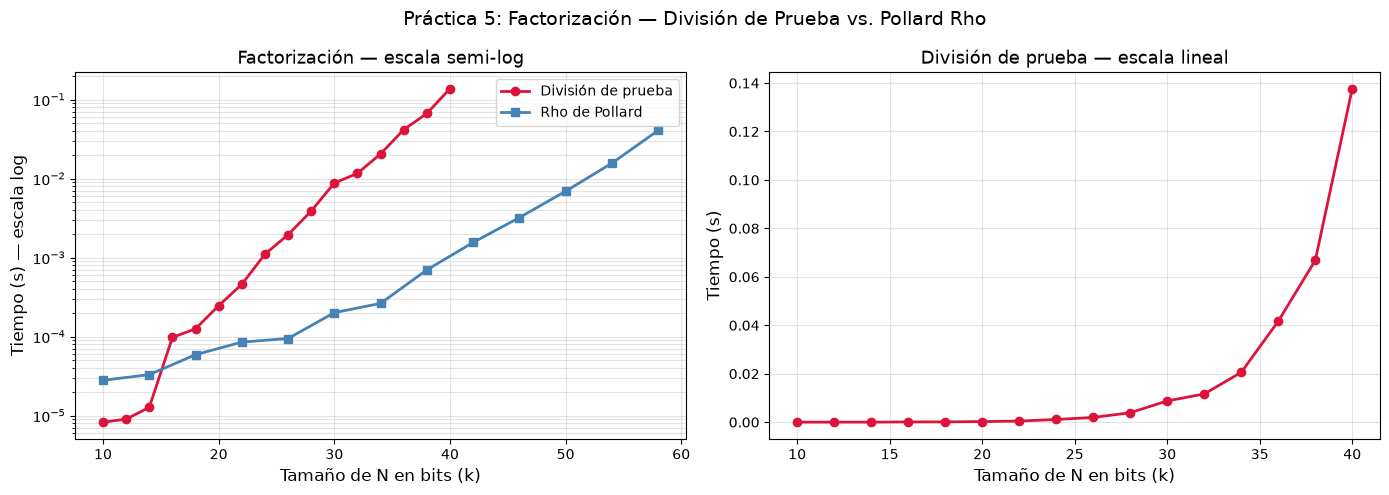

Gráfica guardada como  05_factorizacion_tiempos.png


In [14]:
# ── Celda 7: Gráfica ─────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Escala semi-log en bits
axes[0].semilogy(bits_list,   tiempos_td, "o-", color="crimson",   lw=2, label="División de prueba")
axes[0].semilogy(bits_list_p, tiempos_pr, "s-", color="steelblue", lw=2, label="Rho de Pollard")
axes[0].set_xlabel("Tamaño de N en bits (k)", fontsize=12)
axes[0].set_ylabel("Tiempo (s) — escala log", fontsize=12)
axes[0].set_title("Factorización — escala semi-log", fontsize=13)
axes[0].legend(); axes[0].grid(True, which="both", alpha=0.35)

# Solo división de prueba en escala lineal
axes[1].plot(bits_list, tiempos_td, "o-", color="crimson", lw=2)
axes[1].set_xlabel("Tamaño de N en bits (k)", fontsize=12)
axes[1].set_ylabel("Tiempo (s)", fontsize=12)
axes[1].set_title("División de prueba — escala lineal", fontsize=13)
axes[1].grid(True, alpha=0.35)

plt.suptitle("Práctica 5: Factorización — División de Prueba vs. Pollard Rho", fontsize=14)
plt.tight_layout()
plt.savefig("05_factorizacion_tiempos.png", dpi=110, bbox_inches="tight")
plt.show()
print("Gráfica guardada como  05_factorizacion_tiempos.png")

## 7. Conexión con RSA y preguntas de análisis

### La razón por la que RSA funciona

RSA genera una clave pública $N = p \cdot q$ donde $p$ y $q$ son primos de
$\sim 1024$ bits cada uno. $N$ tiene entonces $\sim 2048$ bits.

Para romper RSA hay que factorizar $N$.
Con el mejor algoritmo clásico conocido (**tamiz del cuerpo de números**, GNFS):
el tiempo es aproximadamente $e^{1.9 (\log N)^{1/3} (\log \log N)^{2/3}}$, que
para $N$ de 2048 bits excede la vida del universo en cualquier computador clásico.

---

**Q1.** En tu medición, ¿cómo crece el tiempo de la división de prueba con el
número de bits $k$? ¿Es la curva lineal en escala semi-log (exponencial en $k$)?

**Q2.** ¿Cuánto más rápido es Pollard respecto a la división de prueba para los
valores de $k$ que mediste? Calcula el cociente de tiempos para $k = 30$.

**Q3.** El problema de factorización está en **NP ∩ co-NP** pero no se sabe si
está en P. ¿Por qué esta posición intermedia lo hace especialmente interesante
para la criptografía?

**Q4.** El **algoritmo de Shor** (cuántico, 1994) factoriza en tiempo
$O((\log N)^3)$ — polinomial. Si se construyera una computadora cuántica lo
suficientemente grande, ¿qué pasaría con RSA y el sistema financiero global?

**Q5.** La **criptografía post-cuántica** (NIST 2022) propone alternativas basadas
en problemas de retículas (lattices) o isogenias de curvas elípticas.
Investiga brevemente: ¿por qué estos problemas podrían ser seguros incluso
frente a computadoras cuánticas?